===== Dataset After Balancing =====
Gamma  : 6688
Hadron : 6688

===== Dataset Split =====
Training: 9363
Validation: 2006
Testing: 2007

===== Manual KNN =====
K = 1  --> Accuracy = 0.7687
K = 3  --> Accuracy = 0.7951
K = 5  --> Accuracy = 0.8026
K = 7  --> Accuracy = 0.8061
K = 9  --> Accuracy = 0.8056

===== Best Model =====
Best K              : 7
Validation Accuracy : 0.8061
Test Accuracy       : 0.8112

===== Scikit-Learn KNN =====
K = 1  --> Accuracy = 0.7687
K = 3  --> Accuracy = 0.7951
K = 5  --> Accuracy = 0.8026
K = 7  --> Accuracy = 0.8061
K = 9  --> Accuracy = 0.8056

===== Best Scikit-Learn Model =====
Best K              : 7
Validation Accuracy : 0.8061
Test Accuracy       : 0.8112

===== Manual KNN Evaluation =====
Accuracy  : 0.8112
Precision : 0.7808
Recall    : 0.8722
F1 Score  : 0.8240

Confusion Matrix
[[887 130]
 [249 741]]

===== Scikit-Learn Evaluation =====
Accuracy  : 0.8112
Precision : 0.7808
Recall    : 0.8722
F1 Score  : 0.8240

Confusion Matrix
[[887 130]


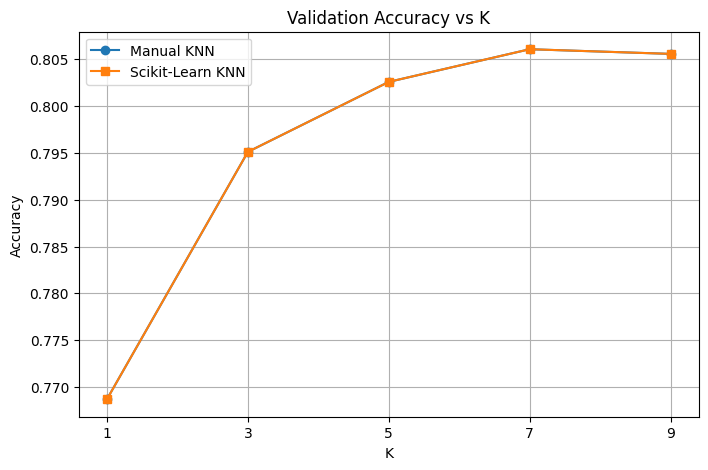

In [4]:
# ==========================================
# 1. Import Libraries
# ==========================================

import os
import pandas as pd
import numpy as np

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import matplotlib.pyplot as plt

# ==========================================
# 2. Read Dataset
# ==========================================

columns = [
    'fLength',
    'fWidth',
    'fSize',
    'fConc',
    'fConc1',
    'fAsym',
    'fM3Long',
    'fM3Trans',
    'fAlpha',
    'fDist',
    'class'
]

# df = pd.read_csv("telescope_data.csv", header=None, names=columns)

import pandas as pd

df = pd.read_csv("telescope_data.csv")

# ==========================================
# 3. Balance Dataset
# ==========================================

gamma = df[df.iloc[:, -1] == 'g']
hadron = df[df.iloc[:, -1] == 'h']

gamma_balanced = gamma.sample(n=len(hadron), random_state=42)

balanced_df = pd.concat([gamma_balanced, hadron])

balanced_df = balanced_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("===== Dataset After Balancing =====")
print(f"Gamma  : {len(gamma_balanced)}")
print(f"Hadron : {len(hadron)}")

# ==========================================
# 4. Split Dataset
# ==========================================

train_df = balanced_df.sample(
    frac=0.70,
    random_state=42
)

remaining_df = balanced_df.drop(train_df.index)

validation_df = remaining_df.sample(
    frac=0.50,
    random_state=42
)

test_df = remaining_df.drop(validation_df.index)
print("\n===== Dataset Split =====")
print("Training:", len(train_df))
print("Validation:", len(validation_df))
print("Testing:", len(test_df))

# ==========================================
# 5. Prepare Features and Labels
# ==========================================

features = [
    'fLength',
    'fWidth',
    'fSize',
    'fConc',
    'fConc1',
    'fAsym',
    'fM3Long',
    'fM3Trans',
    'fAlpha',
    'fDist'
]

X_train = train_df[features]

y_train = train_df['class']

X_validation = validation_df[features]
y_validation = validation_df['class']

X_test = test_df[features]
y_test = test_df['class']

# ==========================================
# 6. Feature Scaling
# ==========================================

X_train = X_train.apply(pd.to_numeric)
X_validation = X_validation.apply(pd.to_numeric)
X_test = X_test.apply(pd.to_numeric)

mean = X_train.mean()
std = X_train.std()

X_train_scaled = (X_train - mean) / std
X_validation_scaled = (X_validation - mean) / std
X_test_scaled = (X_test - mean) / std


# ==========================================
# 7. Manual KNN Functions
# ==========================================

def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((point1 - point2) ** 2))


def get_sorted_neighbors(X_train, test_point):
    distances = np.sqrt(
        np.sum((X_train.values - test_point.values) ** 2, axis=1)
    )

    sorted_indices = np.argsort(distances)

    return [(distances[i], i) for i in sorted_indices]


def predict_class(sorted_neighbors, y_train, k):
    votes = []

    for distance, index in sorted_neighbors[:k]:
        votes.append(y_train.iloc[index])

    prediction = max(set(votes), key=votes.count)

    return prediction


def calculate_accuracy(y_true, y_pred):
    correct = 0

    for i in range(len(y_true)):
        if y_true.iloc[i] == y_pred[i]:
            correct += 1

    accuracy = correct / len(y_true)

    return accuracy


# ==========================================
# 8. Validation (Current Code)
# ==========================================
all_neighbors = []

for i in range(len(X_validation_scaled)):
    sorted_neighbors = get_sorted_neighbors(
        X_train_scaled,
        X_validation_scaled.iloc[i]
    )

    all_neighbors.append(sorted_neighbors)
k_values = [1, 3, 5, 7, 9]
results = {}

print("\n===== Manual KNN =====")
for k in k_values:

    predictions = []
    for i in range(len(X_validation_scaled)):
        prediction = predict_class(
            all_neighbors[i],
            y_train,
            k
        )

        predictions.append(prediction)

    accuracy = calculate_accuracy(
        y_validation,
        predictions
    )

    results[k] = accuracy

    print(f"K = {k:<2} --> Accuracy = {accuracy:.4f}")

# ==========================================
# 9. Select Best K
# ==========================================

best_k = max(results, key=results.get)

print("\n===== Best Model =====")
print(f"Best K              : {best_k}")
print(f"Validation Accuracy : {results[best_k]:.4f}")

# ==========================================
# 10. Test Set Evaluation
# ==========================================
test_neighbors = []

for i in range(len(X_test_scaled)):
    sorted_neighbors = get_sorted_neighbors(
        X_train_scaled,
        X_test_scaled.iloc[i]
    )

    test_neighbors.append(sorted_neighbors)

test_predictions = []

for i in range(len(X_test_scaled)):
    prediction = predict_class(
        test_neighbors[i],
        y_train,
        best_k

    )

    test_predictions.append(prediction)

test_accuracy = calculate_accuracy(
    y_test,
    test_predictions
)

print(f"Test Accuracy       : {test_accuracy:.4f}")

# ==========================================
# 11. Scikit-Learn KNN
# ==========================================

k_values = [1, 3, 5, 7, 9]

sklearn_results = {}

print("\n===== Scikit-Learn KNN =====")

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train_scaled, y_train)

    predictions = knn.predict(X_validation_scaled)

    accuracy = accuracy_score(
        y_validation,
        predictions
    )

    sklearn_results[k] = accuracy

    print(f"K = {k:<2} --> Accuracy = {accuracy:.4f}")

# ==========================================
# 12. Best Scikit-Learn Model
# ==========================================

best_k_sklearn = max(
    sklearn_results,
    key=sklearn_results.get
)

print("\n===== Best Scikit-Learn Model =====")
print(f"Best K              : {best_k_sklearn}")
print(f"Validation Accuracy : {sklearn_results[best_k_sklearn]:.4f}")

# ==========================================
# 13. Test Set Evaluation
# ==========================================

knn = KNeighborsClassifier(
    n_neighbors=best_k_sklearn
)

knn.fit(
    X_train_scaled,
    y_train
)

test_predictions = knn.predict(
    X_test_scaled
)

sklearn_accuracy = accuracy_score(
    y_test,
    test_predictions
)

print(f"Test Accuracy       : {test_accuracy:.4f}")
# ==========================================
# 10.1 Manual KNN Evaluation Metrics
# ==========================================

manual_accuracy = accuracy_score(
    y_test,
    test_predictions
)

manual_precision = precision_score(
    y_test,
    test_predictions,
    pos_label='g'
)

manual_recall = recall_score(
    y_test,
    test_predictions,
    pos_label='g'
)

manual_f1 = f1_score(
    y_test,
    test_predictions,
    pos_label='g'
)

manual_cm = confusion_matrix(
    y_test,
    test_predictions,
    labels=['g', 'h']
)

print("\n===== Manual KNN Evaluation =====")

print(f"Accuracy  : {manual_accuracy:.4f}")
print(f"Precision : {manual_precision:.4f}")
print(f"Recall    : {manual_recall:.4f}")
print(f"F1 Score  : {manual_f1:.4f}")

print("\nConfusion Matrix")
print(manual_cm)
# ==========================================
# 14. Evaluation Metrics
# ==========================================

sklearn_precision = precision_score(
    y_test,
    test_predictions,
    pos_label='g'
)

sklearn_recall = recall_score(
    y_test,
    test_predictions,
    pos_label='g'
)

sklearn_f1 = f1_score(
    y_test,
    test_predictions,
    pos_label='g'
)

sklearn_cm = confusion_matrix(
    y_test,
    test_predictions,
    labels=['g', 'h']
)

print("\n===== Scikit-Learn Evaluation =====")

print(f"Accuracy  : {sklearn_accuracy:.4f}")
print(f"Precision : {sklearn_precision:.4f}")
print(f"Recall    : {sklearn_recall:.4f}")
print(f"F1 Score  : {sklearn_f1:.4f}")

print("\nConfusion Matrix")
print(sklearn_cm)
# ==========================================
print(f"results: {results}")
print(f"sklearn_results: {sklearn_results}")
# ==========================================
# 15. Plot Validation Accuracy vs K
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    list(results.values()),
    marker='o',
    label='Manual KNN'
)

plt.plot(
    k_values,
    list(sklearn_results.values()),
    marker='s',
    label='Scikit-Learn KNN'
)

plt.title("Validation Accuracy vs K")

plt.xlabel("K")

plt.ylabel("Accuracy")

plt.xticks(k_values)

plt.grid(True)

plt.legend()

plt.show()



~~~~DIRECT SOLUTIN~~~~
Before applying regularizer: 
Train MAE: 0.4360652128813752
Train MSE: 0.3596931340421197

Validation MAE: 0.4365083770515734
Validation MSE: 0.3581586296193741

Test MAE: 0.4147573097880798
Test MSE: 0.3191957501196195

After applying regularizer
Best lampda for direct solution: 0.001
Train MAE: 0.43606525252961104
Train MSE: 0.3596931340440584

Validation MAE: 0.43650840810139213
Validation MSE: 0.35815863264373565

Test MAE: 0.4147573651750654
Test MSE: 0.3191957979017147


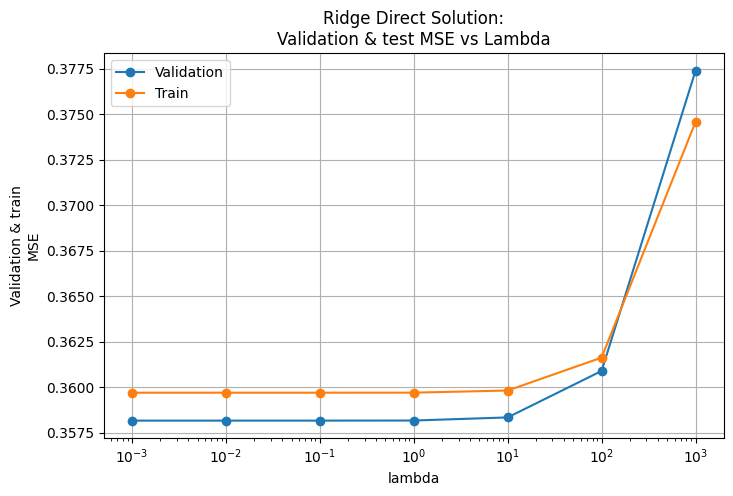

~~~~~GRADIANT DESCENT~~~~

No regularizer:

Train MAE : 0.4435410019018488
Train MSE : 0.3662518814054512

Validation MAE : 0.4456039677872411
Validation MSE : 0.3662622644945249

Test MAE : 0.4235133973417434
Test MSE : 0.3254844573878277

Lasso Gradient Descent:

Train MAE : 0.44248548113798986
Train MSE : 0.3652458533485933

Validation MAE : 0.4442781215632433
Validation MSE : 0.36495627325849905

Test MAE : 0.4224138255905723
Test MSE : 0.32474147818879845

Ridge Gradient Descent:

Train MAE : 0.4423969326877395
Train MSE : 0.36511783977669127

Validation MAE : 0.4441561937098182
Validation MSE : 0.36472633886536593

Test MAE : 0.4223178870365109
Test MSE : 0.3246251781606821


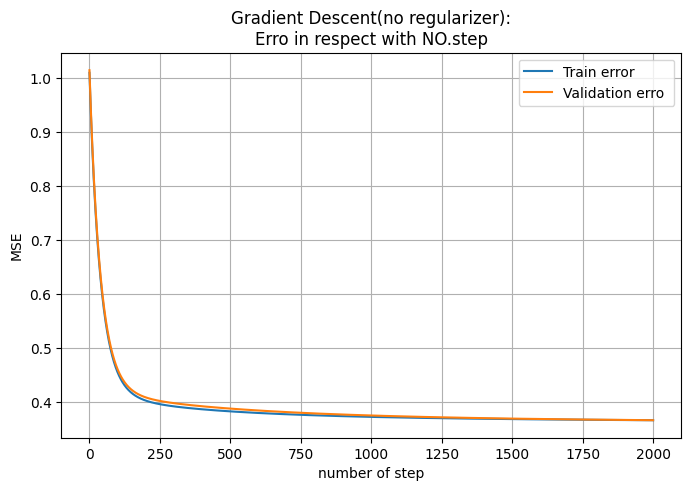

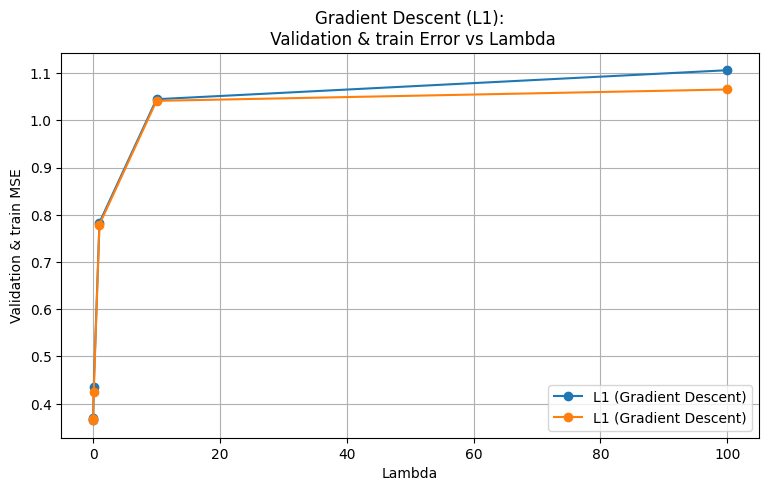

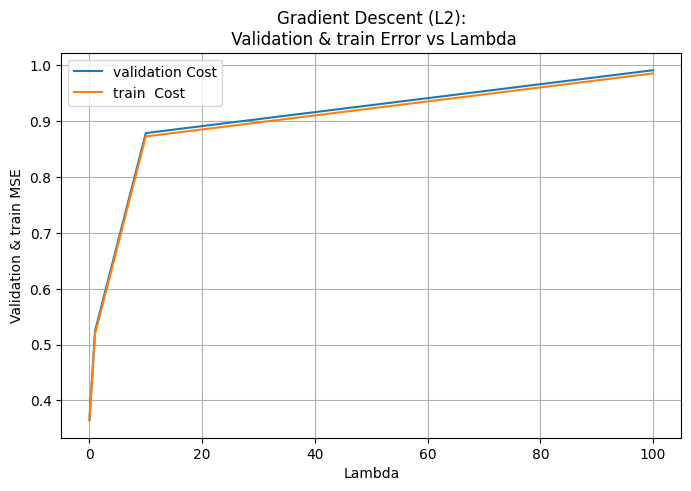

Sklearn
No regularizer

Linear validation MSE : 0.3581586296193745
Linear validation MAE : 0.43650837705157347
Linear Test MSE : 0.3191957501196199
Linear Test MAE : 0.41475730978808

Lasso
Best Lambda for Lasso (L1): 0.001
Lasso Test MSE : 0.32179509295405434
Lasso Test MAE : 0.41773319321097074

Ridge
Best Lambda for Ridge (L2): 0.001

Ridge Test MSE : 0.31919579790171526
Ridge Test MAE : 0.41475736517506556


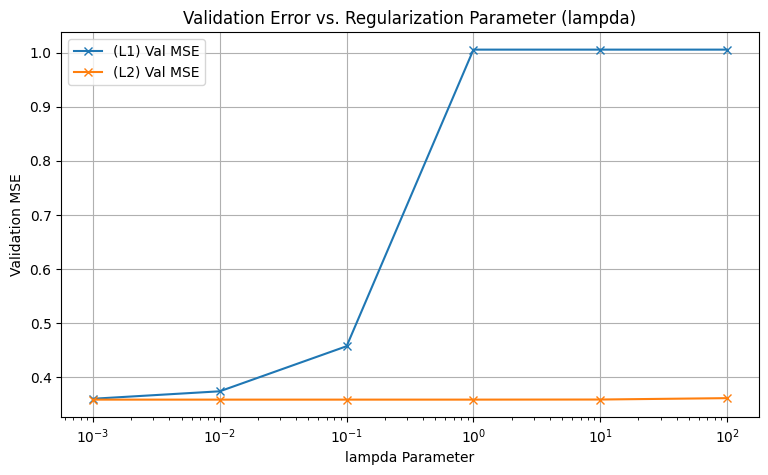

In [6]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error
data = pd.read_csv("California_Houses.csv")
np.random.seed(17)
#_______________________________________________________________________________________
#Data Randomizing
n=len(data)
tr_idx=np.random.choice(np.arange(n),size=int(0.7*n),replace=0) #generate random selection of train data with specific precentage of total data
rm_idx= np.setdiff1d(np.arange(n), tr_idx) #the rest set of data which not included in train
val_idx= np.random.choice(rm_idx, size=int(0.15*n),replace=0) #random selection of validation from rest set
ts_idx_notrandomized= np.setdiff1d(rm_idx, val_idx) #select test from rest set that not included in validation
ts_idx= np.random.choice(ts_idx_notrandomized, size=len(ts_idx_notrandomized),replace=0) #test data randomization
#_________________________________________________________________________________________
#segmentation test_set_train
x= data.drop("Median_House_Value", axis=1)  #create inputs

x=x.to_numpy()  #drive the data to numpy's matrix form
x_train=x[tr_idx]
x_val=x[val_idx]
x_test=x[ts_idx]

y= data["Median_House_Value"] #create targets
y=y.to_numpy()
y_train=y[tr_idx]
y_val=y[val_idx]
y_test=y[ts_idx]
#____________________________________________________________________________________
#Data Normalization
mean = np.mean(x_train, axis=0) #easy way to get mean
std = np.std(x_train, axis=0)  #easy way to get standard deviation
x_train = (x_train - mean) / std
x_val = (x_val - mean) / std
x_test = (x_test - mean) / std

mean=np.mean(y_train,axis=0)
std=np.std(y_train,axis=0)
y_train=(y_train-mean)/std
y_val=(y_val-mean)/std
y_test=(y_test-mean)/std
#__________________________________________________________________________
#Adding Bias
b1 =np.ones((len(x_train), 1 ))# crate a single column matrix with with specefic length
x_train=np.concatenate((b1,x_train),axis=1) #concat that column with the matrix

b2 =np.ones((len(x_val), 1 ))
x_val=np.concatenate((b2,x_val),axis=1)

b3 =np.ones((len(x_test), 1 ))
x_test=np.concatenate((b3,x_test),axis=1)
#_____________________________________________________________________________
#Direct Solution

w_d = np.linalg.inv(x_train.T @ x_train) @ x_train.T @ y_train #apply direct weights eqn

y_pr_train= x_train @ w_d  # find train , validation and test predicted house malue
y_pr_val = x_val @ w_d
y_pr_test = x_test @ w_d


mae_train_d = np.mean(np.abs(y_train - y_pr_train)) #find mean avarge error for direct solution
mae_val_d = np.mean(np.abs(y_val - y_pr_val))
mae_test_d = np.mean(np.abs(y_test - y_pr_test))

mse_train_d = np.mean((y_train - y_pr_train)**2) #find mean squared error
mse_val_d = np.mean((y_val - y_pr_val) ** 2)
mse_test_d = np.mean((y_test - y_pr_test)**2)

#applying regularizer
lambdas = [0.001, 0.01, 0.1, 1, 10, 100,1000]  #array of lambdas in regularizer (penality factor)

I = np.eye(x_train.shape[1])   #lambda matrix
I[0, 0] = 0

best_lam_d = None
best_val_mse_d = float('inf')
w_d_ridge = None
ridge_train_mse=[]   #make an array of error values for different lambdas for train and test
ridge_val_mse = []
for i in lambdas:   #try different values of lambda to find best validation error
    w_temp = np.linalg.inv(x_train.T @ x_train + i* I) @ x_train.T @ y_train #direct solution for weights with regularizer

    train_mse=np.mean((y_train - x_train @ w_temp)**2 ) # find error for each value of lambda for train and validation
    val_mse = np.mean((y_val - x_val @ w_temp)**2 )

    ridge_train_mse.append(train_mse)  #save error values for validation and train in two arrays
    ridge_val_mse.append(val_mse)


    if val_mse < best_val_mse_d:  #the best lambda value is that with least validation error value
        best_val_mse_d = val_mse
        best_lam_d =i
        w_d_ridge = w_temp


y_pri_train= x_train @ w_d_ridge   # find predicted values of houses for train , validation and test
y_pri_val= x_val @w_d_ridge
y_pri_test= x_test @ w_d_ridge

mae_train_rd= np.mean(np.abs(y_train - y_pri_train))  #find mean avarge error for predicted values
mae_val_rd= np.mean(np.abs(y_val - y_pri_val))
mae_test_rd= np.mean(np.abs(y_test - y_pri_test))


mse_train_rd=np.mean((y_train - y_pri_train)**2) #find mean squared error for pr_vls
mse_val_rd=np.mean((y_val - y_pri_val)**2)
mse_test_rd=np.mean((y_test - y_pri_test)**2)

print("="*30)      #print commands
print("~~~~DIRECT SOLUTIN~~~~\nBefore applying regularizer: ")
print("Train MAE:", mae_train_d)
print("Train MSE:", mse_train_d)
print("\nValidation MAE:", mae_val_d)
print("Validation MSE:", mse_val_d)
print("\nTest MAE:", mae_test_d)
print("Test MSE:", mse_test_d)
print("\nAfter applying regularizer\nBest lampda for direct solution:", best_lam_d)
print("Train MAE:", mae_train_rd)
print("Train MSE:", mse_train_rd)
print("\nValidation MAE:", mae_val_rd)
print("Validation MSE:", mse_val_rd)
print("\nTest MAE:", mae_test_rd)
print("Test MSE:", mse_test_rd)
print("="*30)

plt.figure(figsize=(8,5))  #plotting validation and train mean squared error in respect with lambda values
plt.plot(lambdas, ridge_val_mse, marker='o',label="Validation")
plt.plot(lambdas, ridge_train_mse, marker='o', label='Train')
plt.xscale('log')
plt.xlabel("lambda")
plt.ylabel("Validation & train\nMSE")
plt.title("Ridge Direct Solution:\nValidation & test MSE vs Lambda")
plt.legend()
plt.grid(True)
plt.show()

#______________________________________________________________________________
#Gradiant descent

def gradient_descent(X_tr, y_tr, X_v, y_v,lmd , alpha=0.005, steps=2000 , penalty=None  ):

 M, N = X_tr.shape
 np.random.seed(17)

 w = np.random.randn(N) * 0.01   #creat an array of ramdom variables
 train_costs= []
 val_costs= []


 for i in range(steps):
     grad = (2 / M) * (X_tr.T @ (X_tr @ w - y_tr))  #get drivative of initial weights

     reg = np.copy(w)
     reg[0] = 0

     if penalty == "l1":     #penalty selection
         grad += lmd * np.sign(reg)
     elif penalty == "l2":
         grad += 2* lmd * reg

     w -= alpha * grad   #update weights
     reg = np.copy(w)
     reg[0] = 0


     train_error = X_tr @ w - y_tr
     val_error = X_v @ w - y_v

     if penalty == "l1":
          train_cost = np.mean(train_error**2) + lmd * np.sum(np.abs(reg))
          val_cost= np.mean(val_error**2) + lmd * np.sum(np.abs(reg))

     elif penalty == "l2":
       train_cost = np.mean(train_error**2) + lmd * np.sum(reg**2)
       val_cost= np.mean(val_error**2) + lmd * np.sum(reg**2)
     else:
         train_cost = np.mean(train_error**2)
         val_cost= np.mean(val_error**2)

     val_costs.append(val_cost)
     train_costs.append(train_cost)

 return w, train_costs, val_costs



#get weight with no regularizer and also cost
w, train_costs, val_costs =gradient_descent( X_tr=x_train , y_tr=y_train, X_v=x_val, y_v=y_val, lmd=0 ,alpha=0.005, steps=2000,penalty=None )

#random values of lambda

lmda = [ 0.001, 0.01, 0.1, 1, 10,100]
#arrays of errors to get best lambda
l1_val_err = []
l2_val_err = []
l1_train_err = []
l2_trian_error = []


for lam in lmda:  #start to get erros for each lambda's value

    w_l1, _, _ = gradient_descent(x_train, y_train,x_val, y_val,lmd=lam,alpha=0.005,steps=2500,penalty= 'l1' )

    y_val_l1 = x_val @ w_l1
    y_train_l1 = x_train @ w_l1

    l1_val_err.append(np.mean((y_val - y_val_l1) ** 2))
    l1_train_err.append(np.mean((y_train - y_train_l1) ** 2))


    w_l2, _, _ = gradient_descent(x_train, y_train,x_val, y_val,lmd=lam,alpha=0.005, steps=2500,penalty= 'l2' )

    y_val_l2 = x_val @ w_l2
    y_train_l2 = x_train @ w_l2

    l2_val_err.append(np.mean((y_val - y_val_l2) ** 2))
    l2_trian_error.append(np.mean((y_train - y_train_l2) ** 2))





best_l1 = lmda[np.argmin(l1_val_err)] #the best lambda that give the minimum error
best_l2 = lmda[np.argmin(l2_val_err)]

#find expected values of targets with lasso regularizer
w_l1_best, _, _ = gradient_descent(x_train, y_train,x_val, y_val,lmd=best_l1,alpha=0.005,steps=2500,penalty= 'l1' )
y_train_l1 = x_train @ w_l1_best
y_val_l1 = x_val @ w_l1_best
y_test_l1 = x_test @ w_l1_best

#find expected values of targets with ridge regularizer
w_l2_best, _, _ = gradient_descent(x_train, y_train,x_val, y_val,lmd=best_l2,alpha=0.005, steps=2500,penalty= 'l2' )
y_train_l2 = x_train @ w_l2_best
y_val_l2 = x_val @ w_l2_best
y_test_l2 = x_test @ w_l2_best


print("="*30)
print("~~~~~GRADIANT DESCENT~~~~")
print("\nNo regularizer:")
print("\nTrain MAE :", np.mean(np.abs(y_train - x_train @ w)))
print("Train MSE :", np.mean((y_train -x_train @ w )**2))
print("\nValidation MAE :", np.mean(np.abs(y_val - x_val @ w)))
print("Validation MSE :", np.mean((y_val - x_val @ w )**2))
print("\nTest MAE :", np.mean(np.abs(y_test - x_test @ w)))
print("Test MSE :", np.mean((y_test - x_test @ w)**2))

print("\nLasso Gradient Descent:")
print("\nTrain MAE :", np.mean(np.abs(y_train - y_train_l1)))
print("Train MSE :", np.mean((y_train - y_train_l1)**2))
print("\nValidation MAE :", np.mean(np.abs(y_val - y_val_l1)))
print("Validation MSE :", np.mean((y_val - y_val_l1)**2))
print("\nTest MAE :", np.mean(np.abs(y_test - y_test_l1)))
print("Test MSE :", np.mean((y_test - y_test_l1)**2))

print("\nRidge Gradient Descent:")
print("\nTrain MAE :", np.mean(np.abs(y_train - y_train_l2)))
print("Train MSE :", np.mean((y_train - y_train_l2)**2))
print("\nValidation MAE :", np.mean(np.abs(y_val - y_val_l2)))
print("Validation MSE :", np.mean((y_val - y_val_l2)**2))
print("\nTest MAE :", np.mean(np.abs(y_test - y_test_l2)))
print("Test MSE :", np.mean((y_test - y_test_l2)**2))
print("="*30)

plt.figure(figsize=(8,5))
plt.plot(train_costs, label="Train error")
plt.plot(val_costs, label="Validation erro ")
plt.xlabel("number of step")
plt.ylabel("MSE")
plt.title("Gradient Descent(no regularizer):\nErro in respect with NO.step")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(9,5))
plt.plot(lmda, l1_val_err, marker='o', label='L1 (Gradient Descent)')
plt.plot(lmda, l1_train_err, marker='o', label='L1 (Gradient Descent)')
plt.xlabel("Lambda")
plt.ylabel("Validation & train MSE")
plt.title("Gradient Descent (L1):\n Validation & train Error vs Lambda")
plt.legend()
plt.grid(True)
plt.show()



plt.figure(figsize=(8,5))
plt.plot(lmda,l2_val_err, label="validation Cost")
plt.plot(lmda,l2_trian_error, label="train  Cost")
plt.xlabel("Lambda")
plt.ylabel("Validation & train MSE")
plt.title("Gradient Descent (L2):\n Validation & train Error vs Lambda")
plt.legend()
plt.grid(True)
plt.show()

#__________________________________________________
#sklearn
model = LinearRegression(fit_intercept=False)
model.fit(x_train, y_train)

y_pr_val = model.predict(x_val)
y_pr_test=model.predict(x_test)

lmda = [0.001, 0.01, 0.1, 1, 10, 100]
l1_val_err = []
l2_val_err = []

for i in lmda:
    #L1
    lasso = Lasso(alpha=i,fit_intercept=False)
    lasso.fit(x_train, y_train)
    val_pr_l1 = lasso.predict(x_val)
    l1_val_err.append(mean_squared_error(y_val, val_pr_l1))
    #L2
    ridge = Ridge(alpha=i,fit_intercept=False)
    ridge.fit(x_train, y_train)
    val_pr_l2 = ridge.predict(x_val)
    l2_val_err.append(mean_squared_error(y_val, val_pr_l2))



best_l1 = lmda[np.argmin(l1_val_err)]
best_l2 = lmda[np.argmin(l2_val_err)]

best_lasso = Lasso(alpha=best_l1, fit_intercept=False)
best_lasso.fit(x_train, y_train)
y_test_lasso = best_lasso.predict(x_test)
best_ridge = Ridge(alpha=best_l2, fit_intercept=False)
best_ridge.fit(x_train, y_train)
y_test_ridge = best_ridge.predict(x_test)
print("="*30+"\nSklearn")
print("No regularizer\n")
print("Linear validation MSE :", mean_squared_error(y_val, y_pr_val))
print("Linear validation MAE :", mean_absolute_error(y_val, y_pr_val))
print("Linear Test MSE :", mean_squared_error(y_test, y_pr_test))
print("Linear Test MAE :", mean_absolute_error(y_test, y_pr_test))
print(f"\nLasso\nBest Lambda for Lasso (L1): {best_l1}")
print("Lasso Test MSE :", mean_squared_error(y_test, y_test_lasso))
print("Lasso Test MAE :", mean_absolute_error(y_test, y_test_lasso))
print(f"\nRidge\nBest Lambda for Ridge (L2): {best_l2}")
print("\nRidge Test MSE :", mean_squared_error(y_test, y_test_ridge))
print("Ridge Test MAE :", mean_absolute_error(y_test, y_test_ridge))

print("="*30)
plt.figure(figsize=(9, 5))
plt.plot(lmda, l1_val_err, marker='x', label='(L1) Val MSE')
plt.plot(lmda, l2_val_err, marker='x', label='(L2) Val MSE')
plt.xscale('log')
plt.xlabel('lampda Parameter')
plt.ylabel('Validation MSE')
plt.title('Validation Error vs. Regularization Parameter (lampda)')
plt.legend()
plt.grid(True)
plt.show()
